In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
!pip install -q datasets

In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("coldstart88/triageiq-dataset")

df = dataset["train"].to_pandas()

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)
df.head()

README.md:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 87.3kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 22.0kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/1399 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/302 [00:00<?, ? examples/s]

Dataset loaded successfully! ✅
Shape: (1399, 4)


,text,sentiment,urgency,category
0,this is urgent but also — whoever helped me ju...,positive,high,other
1,been waiting 3 weeks for a refund and every ti...,negative,medium,other
2,been waiting on this delivery longer than expe...,positive,medium,other
3,do you guys do weekend deliveries or is it str...,neutral,medium,other
4,my subscription renewed but i lost access at t...,neutral,high,other


In [4]:
print(df["category"].value_counts())

category
other              281
feature_request    280
billing            280
technical          280
account            278
Name: count, dtype: int64


In [5]:
print(df["urgency"].value_counts())

urgency
low       469
high      468
medium    462
Name: count, dtype: int64


In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,this is urgent but also — whoever helped me ju...,this is urgent but also whoever helped me just...
1,been waiting 3 weeks for a refund and every ti...,been waiting weeks for a refund and every time...
2,been waiting on this delivery longer than expe...,been waiting on this delivery longer than expe...
3,do you guys do weekend deliveries or is it str...,do you guys do weekend deliveries or is it str...
4,my subscription renewed but i lost access at t...,my subscription renewed but i lost access at t...


In [7]:
df.to_csv("clean_support_tickets.csv", index=False)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        1399 non-null   object
 1   sentiment   1399 non-null   object
 2   urgency     1399 non-null   object
 3   category    1399 non-null   object
 4   clean_text  1399 non-null   object
dtypes: object(5)
memory usage: 54.8+ KB


In [9]:
df.isnull().sum()

,0
text,0
sentiment,0
urgency,0
category,0
clean_text,0


In [10]:
df.describe(include="all")

,text,sentiment,urgency,category,clean_text
count,1399,1399,1399,1399,1399
unique,1398,3,3,5,1398
top,omg THANK YOU for fixing that double charge so...,neutral,low,other,omg thank you for fixing that double charge so...
freq,2,473,469,281,2


In [11]:
print("Ticket Categories:")
print(df["category"].value_counts())

print("\nUrgency Levels:")
print(df["urgency"].value_counts())

Ticket Categories:
category
other              281
feature_request    280
billing            280
technical          280
account            278
Name: count, dtype: int64

Urgency Levels:
urgency
low       469
high      468
medium    462
Name: count, dtype: int64


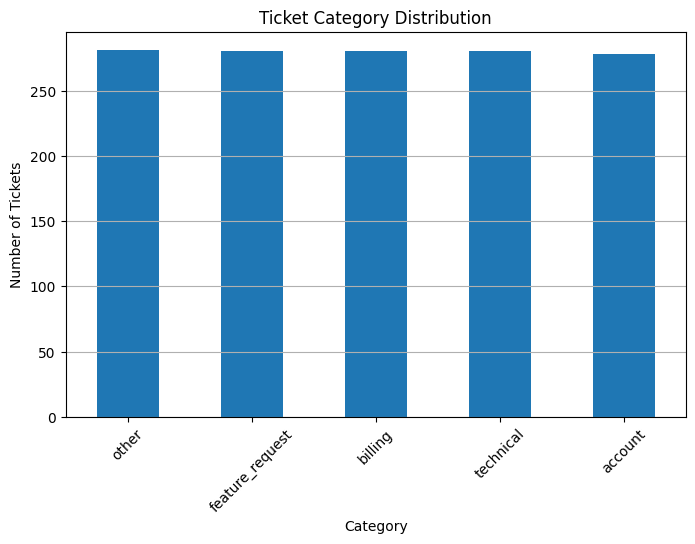

In [12]:
plt.figure(figsize=(8, 5))
df["category"].value_counts().plot(kind="bar")

plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

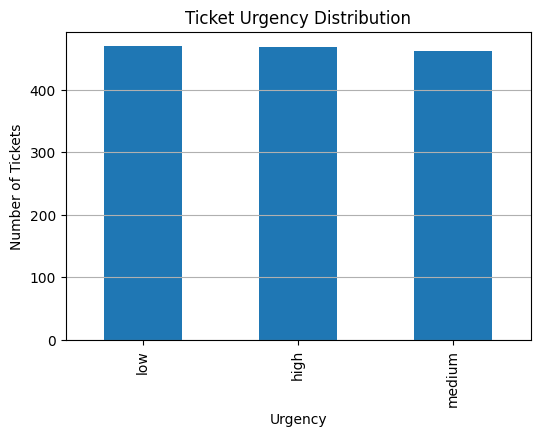

In [13]:
plt.figure(figsize=(6, 4))
df["urgency"].value_counts().plot(kind="bar")

plt.title("Ticket Urgency Distribution")
plt.xlabel("Urgency")
plt.ylabel("Number of Tickets")
plt.grid(axis="y")
plt.show()

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF conversion completed! ")
print("Shape of TF-IDF matrix:", X.shape)

TF-IDF conversion completed! 
Shape of TF-IDF matrix: (1399, 1909)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["category"],
    test_size=0.2,
    random_state=42,
    stratify=df["category"]
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1119, 1909)
Testing data: (280, 1909)


In [17]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000)

model_category.fit(X_train, y_train)

print("Category classification model trained successfully! ")

Category classification model trained successfully! 


In [19]:
category_predictions = model_category.predict(X_test)

print("Category predictions created successfully! ✅")
print(category_predictions[:10])

Category predictions created successfully! ✅
['billing' 'feature_request' 'account' 'account' 'technical' 'account'
 'billing' 'account' 'technical' 'billing']


In [20]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, category_predictions)

print("Category Classification Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, category_predictions))

Category Classification Accuracy: 0.8464285714285714

Classification Report:
                 precision    recall  f1-score   support

        account       0.80      0.84      0.82        56
        billing       0.94      0.89      0.92        56
feature_request       0.93      0.89      0.91        56
          other       0.76      0.79      0.77        56
      technical       0.82      0.82      0.82        56

       accuracy                           0.85       280
      macro avg       0.85      0.85      0.85       280
   weighted avg       0.85      0.85      0.85       280



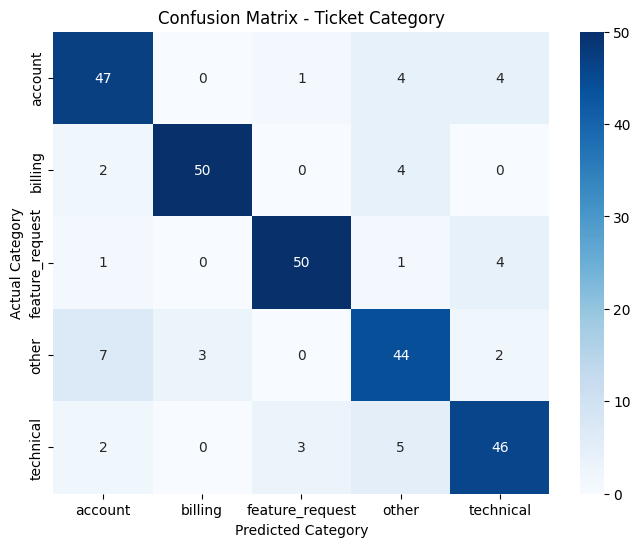

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, category_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model_category.classes_,
    yticklabels=model_category.classes_
)

plt.title("Confusion Matrix - Ticket Category")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [22]:
X_train_urgency, X_test_urgency, y_train_urgency, y_test_urgency = train_test_split(
    X,
    df["urgency"],
    test_size=0.2,
    random_state=42,
    stratify=df["urgency"]
)

print("Urgency training data:", X_train_urgency.shape)
print("Urgency testing data:", X_test_urgency.shape)

Urgency training data: (1119, 1909)
Urgency testing data: (280, 1909)


In [25]:
model_urgency = LogisticRegression(max_iter=1000)

model_urgency.fit(X_train_urgency, y_train_urgency)

print("Urgency classification model trained successfully!")

Urgency classification model trained successfully!


In [26]:
from sklearn.linear_model import LogisticRegression

model_urgency = LogisticRegression(max_iter=1000)

model_urgency.fit(X_train_urgency, y_train_urgency)

print("Urgency classification model trained successfully! ")

Urgency classification model trained successfully! 


In [27]:
urgency_predictions = model_urgency.predict(X_test_urgency)

print("Urgency predictions created successfully! ✅")
print(urgency_predictions[:10])

Urgency predictions created successfully! ✅
['low' 'low' 'medium' 'medium' 'low' 'high' 'high' 'high' 'medium'
 'medium']


In [28]:
from sklearn.metrics import accuracy_score, classification_report

urgency_accuracy = accuracy_score(y_test_urgency, urgency_predictions)

print("Urgency Classification Accuracy:", urgency_accuracy)

print("\nClassification Report:")
print(classification_report(y_test_urgency, urgency_predictions))

Urgency Classification Accuracy: 0.6285714285714286

Classification Report:
              precision    recall  f1-score   support

        high       0.82      0.85      0.84        94
         low       0.55      0.61      0.58        94
      medium       0.49      0.42      0.46        92

    accuracy                           0.63       280
   macro avg       0.62      0.63      0.62       280
weighted avg       0.62      0.63      0.62       280



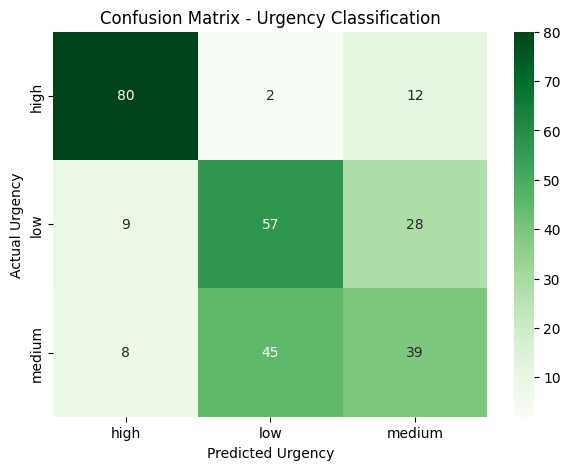

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_urgency = confusion_matrix(
    y_test_urgency,
    urgency_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_urgency,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=model_urgency.classes_,
    yticklabels=model_urgency.classes_
)

plt.title("Confusion Matrix - Urgency Classification")
plt.xlabel("Predicted Urgency")
plt.ylabel("Actual Urgency")
plt.show()

In [30]:
new_ticket = ["I cannot access my account and need help urgently"]

new_ticket_clean = [clean_text(new_ticket[0])]

new_ticket_vector = vectorizer.transform(new_ticket_clean)

predicted_category = model_category.predict(new_ticket_vector)[0]
predicted_urgency = model_urgency.predict(new_ticket_vector)[0]

print("Ticket:", new_ticket[0])
print("Predicted Category:", predicted_category)
print("Predicted Urgency:", predicted_urgency)

Ticket: I cannot access my account and need help urgently
Predicted Category: account
Predicted Urgency: high


In [31]:
results = pd.DataFrame({
    "Task": [
        "Ticket Category Classification",
        "Ticket Urgency Classification"
    ],
    "Accuracy": [
        accuracy,
        urgency_accuracy
    ]
})

print(results)

                             Task  Accuracy
0  Ticket Category Classification  0.846429
1   Ticket Urgency Classification  0.628571


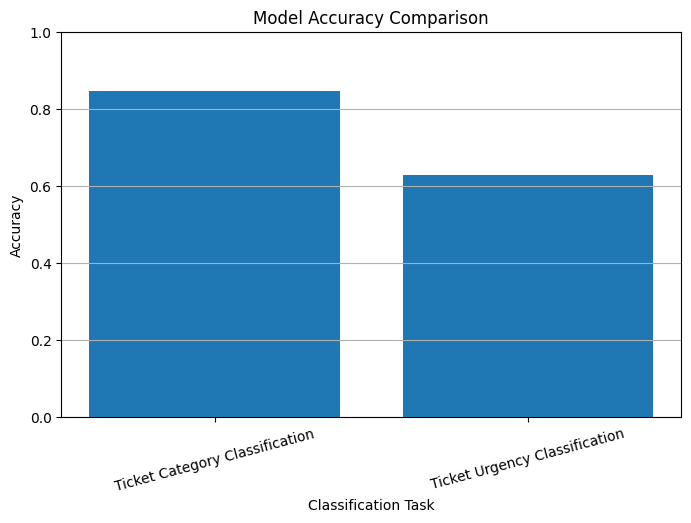

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(results["Task"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Classification Task")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

Business Insights

- The model can automatically classify customer support tickets into different categories.
- The model can also identify ticket urgency as High, Medium, or Low.
- TF-IDF was used to convert customer support text into numerical features.
- Logistic Regression was used for both category and urgency classification.
- The confusion matrices help identify correctly and incorrectly classified tickets.
- This type of system can help support teams organize incoming tickets and prioritize urgent requests.

Conclusion

A machine learning-based support ticket classification system was developed
using customer support text data. Text preprocessing and TF-IDF feature
extraction were used to convert ticket descriptions into numerical features.
Logistic Regression models were trained to classify tickets by category and
urgency level. The models were evaluated using accuracy, precision, recall,
F1-score, and confusion matrices.

The project demonstrates how Natural Language Processing (NLP) and machine
learning can assist in organizing support tickets and identifying urgent
requests.